# Online Retail

- InvoiceNo	ID	Categorical	a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
- StockCode	ID	Categorical	a 5-digit integral number uniquely assigned to each distinct product
- Description	Feature	Categorical	product name
- Quantity	Feature	Integer	the quantities of each product - (item) per transaction
- InvoiceDate	Feature	Date	the day and time when each - transaction was generated
- UnitPrice	Feature	Continuous	product price per unit	sterling
- CustomerID	Feature	Categorical	a 5-digit integral number - uniquely assigned to each customer
- Country	Feature	Categorical	the name of the country where each customer resides

In [3]:
import numpy as np
import pandas as pd 

# Ignorar avisos irrelevantes
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_excel("OnlineRetail.xlsx")
df = df.sample(n=50000, random_state=42)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [5]:
df.shape

(50000, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Investigámos a existencia de valores nulos.

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 50000 entries, 209268 to 442368
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    50000 non-null  object        
 1   StockCode    50000 non-null  object        
 2   Description  49860 non-null  object        
 3   Quantity     50000 non-null  int64         
 4   InvoiceDate  50000 non-null  datetime64[us]
 5   UnitPrice    50000 non-null  float64       
 6   CustomerID   37396 non-null  float64       
 7   Country      50000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 4.1+ MB


InvoiceNo          0
StockCode          0
Description      140
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     12604
Country            0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(37396, 8)


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 37396 entries, 209268 to 442368
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    37396 non-null  object        
 1   StockCode    37396 non-null  object        
 2   Description  37396 non-null  object        
 3   Quantity     37396 non-null  int64         
 4   InvoiceDate  37396 non-null  datetime64[us]
 5   UnitPrice    37396 non-null  float64       
 6   CustomerID   37396 non-null  float64       
 7   Country      37396 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 3.0+ MB


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

ver duplicados

In [10]:
df.duplicated().sum()

52

In [11]:
duplicados = df[df.duplicated(keep=False)]

duplicados_ordenados = duplicados.sort_values(by=['InvoiceNo', 'StockCode', 'Quantity'])

duplicados_ordenados.head(12)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
8765,537144,21882,SKULLS TAPE,1,2010-12-05 13:00:00,0.65,15880.0,United Kingdom
8705,537144,21882,SKULLS TAPE,1,2010-12-05 13:00:00,0.65,15880.0,United Kingdom
25383,538368,22195,LARGE HEART MEASURING SPOONS,1,2010-12-12 10:57:00,1.65,15503.0,United Kingdom
25385,538368,22195,LARGE HEART MEASURING SPOONS,1,2010-12-12 10:57:00,1.65,15503.0,United Kingdom
34061,539317,22443,GROW YOUR OWN HERBS SET OF 3,1,2010-12-16 19:04:00,7.95,17392.0,United Kingdom
34050,539317,22443,GROW YOUR OWN HERBS SET OF 3,1,2010-12-16 19:04:00,7.95,17392.0,United Kingdom
51582,540647,84947,ANTIQUE SILVER TEA GLASS ENGRAVED,6,2011-01-10 14:57:00,1.25,17406.0,United Kingdom
51581,540647,84947,ANTIQUE SILVER TEA GLASS ENGRAVED,6,2011-01-10 14:57:00,1.25,17406.0,United Kingdom
83449,543306,22539,MINI JIGSAW DOLLY GIRL,1,2011-02-07 11:56:00,0.42,16686.0,United Kingdom
83437,543306,22539,MINI JIGSAW DOLLY GIRL,1,2011-02-07 11:56:00,0.42,16686.0,United Kingdom


In [12]:
df = df.drop_duplicates()
print(df.shape)

(37344, 8)


Investigar se os stockcodes correspondiam sempre à mesma description

In [13]:
df.groupby('StockCode')['Description'].nunique()[lambda x: x > 1]

StockCode
21112     2
21175     2
21232     2
21243     2
21507     2
         ..
84997B    2
84997C    2
84997D    2
85184C    2
85185B    2
Name: Description, Length: 105, dtype: int64

Fomos ver individualmente o que estava a acontecer e notou-se um padrão. Mas que eram necessariamente os mesmos produtos.

In [14]:
df[df['StockCode'].astype(str) == '21112']['Description'].unique()

array(['SWISS ROLL TOWEL PINK  SPOTS', 'SWISS ROLL TOWEL, PINK  SPOTS'],
      dtype=object)

In [15]:
df[df['StockCode'].astype(str) == '21175']['Description'].unique()

array(['GIN + TONIC DIET METAL SIGN', 'GIN AND TONIC DIET METAL SIGN'],
      dtype=object)

In [16]:
df[df['StockCode'].astype(str) == '21232']['Description'].unique()

array(['STRAWBERRY CERAMIC TRINKET BOX', 'STRAWBERRY CERAMIC TRINKET POT'],
      dtype=object)

In [17]:
df[df['StockCode'].astype(str) == '85185B']['Description'].unique()

array(['PINK HORSE SOCK PUPPET KIT', 'PINK HORSE SOCK PUPPET'],
      dtype=object)

## Limpar as variáveis numéricas que estavam como objeto

Observar os casos de StockCode que não estão numéricos.

In [18]:
df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].value_counts()


StockCode
85123A    183
85099B    157
POST      109
82494L     94
85099F     64
         ... 
35912B      1
17090A      1
90200E      1
72800D      1
84951B      1
Name: count, Length: 519, dtype: int64

Investigar um caso concreto

In [19]:
df[df['StockCode'].astype(str).str.startswith('90214')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
527050,580691,90214C,"LETTER ""C"" BLING KEY RING",12,2011-12-05 15:48:00,0.29,13790.0,United Kingdom
17502,537765,90214K,"LETTER ""K"" BLING KEY RING",1,2010-12-08 12:08:00,1.25,14606.0,United Kingdom
540095,581467,90214C,"LETTER ""C"" BLING KEY RING",1,2011-12-08 19:24:00,0.29,13077.0,United Kingdom
538792,581414,90214R,"LETTER ""R"" BLING KEY RING",1,2011-12-08 14:39:00,0.29,14730.0,United Kingdom
527048,580691,90214A,"LETTER ""A"" BLING KEY RING",12,2011-12-05 15:48:00,0.29,13790.0,United Kingdom


Investigar outro caso

In [20]:
df[df['StockCode'].astype(str).str.startswith('85123')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
195717,553739,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2011-05-19 09:23:00,2.95,14895.0,United Kingdom
44938,540247,85123A,WHITE HANGING HEART T-LIGHT HOLDER,3,2011-01-05 15:56:00,2.95,15464.0,United Kingdom
183297,552655,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2,2011-05-10 14:22:00,2.95,14587.0,United Kingdom
12896,537400,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-06 14:36:00,2.95,17191.0,United Kingdom
68006,541849,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2011-01-23 13:34:00,2.95,13230.0,United Kingdom


Eliminar o que estiver à frente dos 5 digitos

In [21]:
df['StockCode'] = df['StockCode'].astype(str).str[:5]

Ver se ainda há letras ou símbolos no stockcode.

In [22]:
df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].value_counts()

StockCode
POST     109
M         33
C2        12
D          4
CRUK       3
BANK       2
PADS       1
DOT        1
Name: count, dtype: int64

Eliminar o que restava e passar a variável para numérica.

In [23]:
df = df[df['StockCode'].astype(str).str.isnumeric()]
df['StockCode'] = df['StockCode'].astype(int)

Ver se tudo parece bater certo.

In [24]:
df.sort_values('StockCode').head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
65899,541698,10002,INFLATABLE POLITICAL GLOBE,18,2011-01-20 19:16:00,0.85,14713.0,United Kingdom
127450,547223,10002,INFLATABLE POLITICAL GLOBE,5,2011-03-21 15:10:00,0.85,12867.0,United Kingdom
20617,538069,10002,INFLATABLE POLITICAL GLOBE,8,2010-12-09 14:08:00,0.85,16795.0,United Kingdom
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France
142354,548606,10002,INFLATABLE POLITICAL GLOBE,120,2011-04-01 11:10:00,0.85,12731.0,France


Ver o resultado final.

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 37179 entries, 209268 to 442368
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    37179 non-null  object        
 1   StockCode    37179 non-null  int32         
 2   Description  37179 non-null  object        
 3   Quantity     37179 non-null  int64         
 4   InvoiceDate  37179 non-null  datetime64[us]
 5   UnitPrice    37179 non-null  float64       
 6   CustomerID   37179 non-null  float64       
 7   Country      37179 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), object(2), str(1)
memory usage: 2.9+ MB


Viu-se que o InvoiceNo também ainda está como objeto e deve ser portando tratado.

Observar os casos de InvoiceNo que não estão numéricos.

In [26]:
df[~df['InvoiceNo'].astype(str).str.isnumeric()]['InvoiceNo'].value_counts()

InvoiceNo
C570867    9
C548460    8
C569655    6
C569985    6
C562952    5
          ..
C550027    1
C560932    1
C551465    1
C551551    1
C581465    1
Name: count, Length: 638, dtype: int64

Eliminar as compras que foram canceladas

In [27]:
df = df[df['StockCode'].astype(str).str.isnumeric()]
df['StockCode'] = df['StockCode'].astype(int)

Ver o resultado final.

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 37179 entries, 209268 to 442368
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    37179 non-null  object        
 1   StockCode    37179 non-null  int32         
 2   Description  37179 non-null  object        
 3   Quantity     37179 non-null  int64         
 4   InvoiceDate  37179 non-null  datetime64[us]
 5   UnitPrice    37179 non-null  float64       
 6   CustomerID   37179 non-null  float64       
 7   Country      37179 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), object(2), str(1)
memory usage: 2.9+ MB


In [29]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


observar numéricas estatisticamente

In [30]:
df.describe()

,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID
count,37179.000000,37179.000000,37179,37179.000000,37179.000000
mean,30744.864897,13.903333,2011-07-10 11:39:26.469781,2.889334,15282.047850
min,10002.000000,-432.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,22041.000000,2.000000,2011-04-07 11:22:30,1.250000,13969.000000
50%,22666.000000,5.000000,2011-07-31 11:48:00,1.950000,15117.000000
75%,23265.000000,12.000000,2011-10-20 12:07:00,3.750000,16790.000000
max,90214.000000,74215.000000,2011-12-09 12:50:00,295.000000,18287.000000
std,20615.143351,386.941306,NaN,3.828785,1710.862062


In [31]:
# Remover quantidades e preços inválidos
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

coluna revenue

In [32]:
# Criar coluna Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,20.40
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,27.80
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,2.60
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,5.85
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,19.90


tirar descrição

In [34]:
# Descartar colunas desnecessárias
df_semdesc = df.drop(columns=['Description'])

## EDA

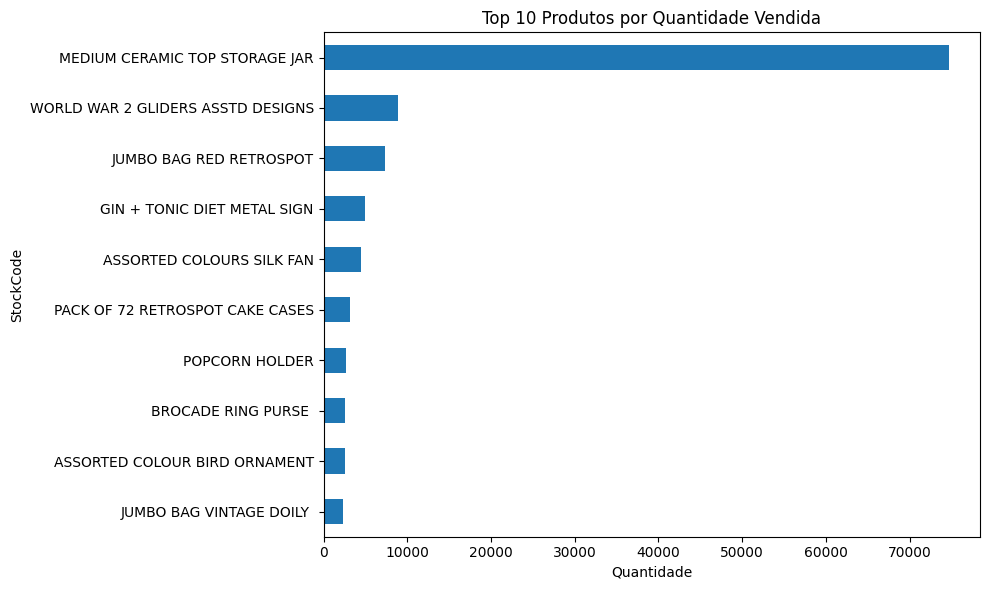

In [35]:
import matplotlib.pyplot as plt
# Top 10 produtos por quantidade vendida
top_qty = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
desc_map = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
top_qty.index = top_qty.index.map(desc_map)
top_qty.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 10 Produtos por Quantidade Vendida')
plt.xlabel('Quantidade')
plt.tight_layout(); plt.show()

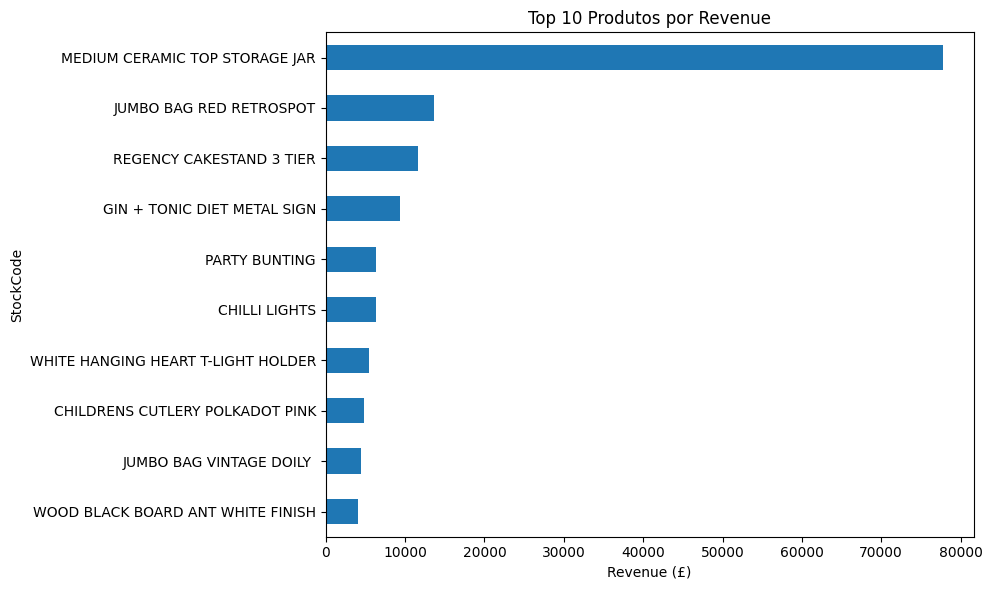

In [36]:
# Top 10 produtos por revenue
top_products = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False).head(10)
desc_map = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
top_products.index = top_products.index.map(desc_map)
top_products.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 10 Produtos por Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout(); plt.show()

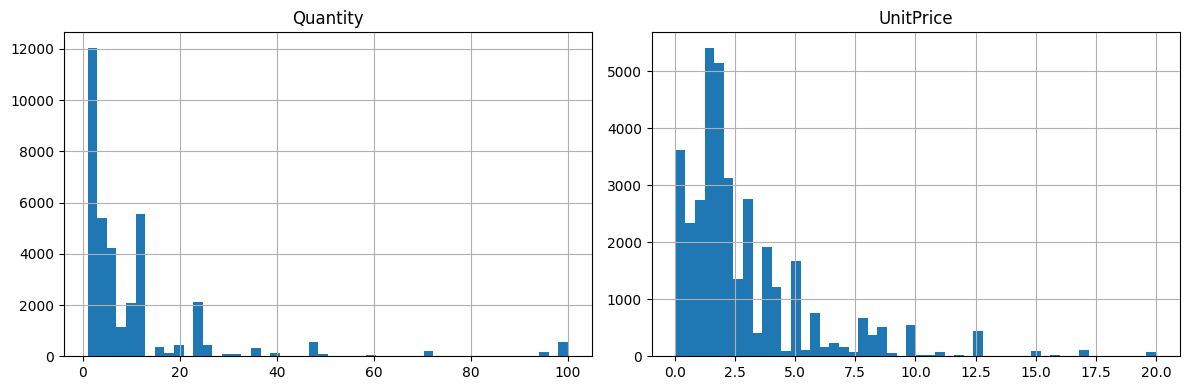

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Quantity'].clip(upper=100).hist(bins=50, ax=axes[0])
axes[0].set_title('Quantity')
df['UnitPrice'].clip(upper=20).hist(bins=50, ax=axes[1])
axes[1].set_title('UnitPrice')
plt.tight_layout(); plt.show()

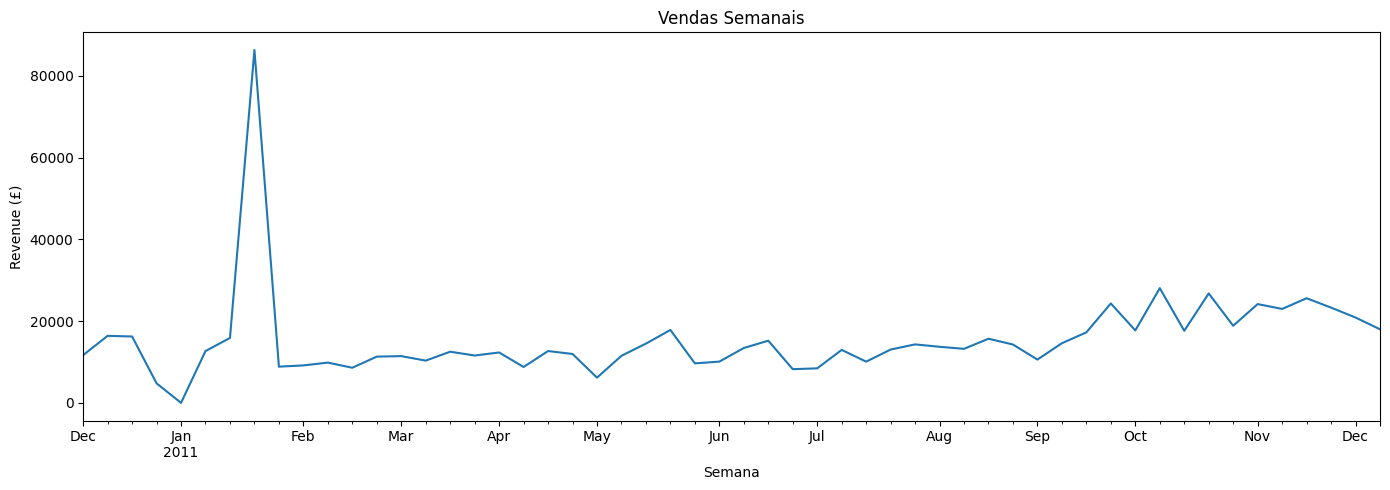

In [38]:
# Vendas semanais
vendas_semanal = df.set_index('InvoiceDate').resample('W')['Revenue'].sum()
vendas_semanal.plot(kind='line', figsize=(14, 5), title='Vendas Semanais')
plt.xlabel('Semana')
plt.ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

In [39]:
import plotly.express as px

# Vendas por mês
df['Month-Year'] = df['InvoiceDate'].dt.strftime('%m-%Y')
vendas_mes = df.groupby('Month-Year')['Revenue'].sum().reset_index()
vendas_mes = vendas_mes.sort_values('Month-Year')

fig = px.bar(vendas_mes, x='Month-Year', y='Revenue',
             color='Revenue',
             labels={'Revenue': 'Revenue (£)', 'Month-Year': 'Mês'},
             title='Vendas Mensais')

fig.update_layout(width=900, height=500)
fig.show()


Tem picos claros, possivelmente nas vendas de natal e depois nos saldos.

tratar a data para numérica ter em conta a diferença temporal do inicio até ao dia, tambémp permitir sazonalidade mantendo o month.

In [40]:
reference_date = df_semdesc['InvoiceDate'].min()
df_semdesc['DaysSinceStart'] = (df_semdesc['InvoiceDate'] - reference_date).dt.days
df_semdesc['Month'] = df_semdesc['InvoiceDate'].dt.month
df_semdesc = df_semdesc.drop(columns=['InvoiceDate'])

## Label encoding

encoding do country

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df_semdesc.copy()
df_encoded['Country'] = le.fit_transform(df_semdesc['Country'])


In [42]:
df_encoded.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Revenue,DaysSinceStart,Month
209268,555200,71459,24,0.85,17315.0,34,20.40,182,6
207108,554974,21128,4,6.95,14031.0,34,27.80,177,5
167085,550972,21086,4,0.65,14031.0,34,2.60,141,4
471836,576652,22812,3,1.95,17198.0,34,5.85,350,11
115865,546157,22180,2,9.95,13502.0,34,19.90,99,3


## Scaling

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
continuous = ['Quantity', 'UnitPrice', 'Revenue', 'DaysSinceStart', 'Month']
df_encoded[continuous] = scaler.fit_transform(df_encoded[continuous])
df_encoded.head()


,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Revenue,DaysSinceStart,Month
209268,555200,71459,0.000310,0.002746,17315.0,34,0.000263,0.487936,0.454545
207108,554974,21128,0.000040,0.023427,14031.0,34,0.000359,0.474531,0.363636
167085,550972,21086,0.000040,0.002068,14031.0,34,0.000032,0.378016,0.272727
471836,576652,22812,0.000027,0.006475,17198.0,34,0.000074,0.938338,0.909091
115865,546157,22180,0.000013,0.033598,13502.0,34,0.000256,0.265416,0.181818


In [44]:
df_pronto = df_encoded.drop(columns=['InvoiceNo', 'StockCode', 'CustomerID'])
df_pronto.head()

,Quantity,UnitPrice,Country,Revenue,DaysSinceStart,Month
209268,0.000310,0.002746,34,0.000263,0.487936,0.454545
207108,0.000040,0.023427,34,0.000359,0.474531,0.363636
167085,0.000040,0.002068,34,0.000032,0.378016,0.272727
471836,0.000027,0.006475,34,0.000074,0.938338,0.909091
115865,0.000013,0.033598,34,0.000256,0.265416,0.181818


## Agrupar Transações

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Agrupa todos os produtos de cada fatura numa lista
basket = df.groupby('InvoiceNo')['Description'].apply(list).reset_index(drop=True)

# TransactionEncoder converte as listas de itens numa matriz booleana:
# cada coluna é um produto, cada linha é uma fatura, True = produto presente
encoder = TransactionEncoder()
encoded_data = encoder.fit_transform(basket)

# Transforma o array numpy num DataFrame legível
transactions = pd.DataFrame(encoded_data, columns=encoder.columns_)
transactions.head()

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Apriori — Itens Frequentes

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# min_support=0.005 → produto em ≥0.5% das faturas (~62 faturas)
# O produto mais popular só tem 1.45%, por isso 0.02 excluía quase tudo
frequent_itemsets = apriori(transactions, min_support=0.005, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"Itemsets frequentes encontrados: {len(frequent_itemsets)}")
frequent_itemsets.sort_values('support', ascending=False).head(20)

## Regras de Associação

In [ ]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules[rules['confidence'] >= 0.2].sort_values('lift', ascending=False)
print(f"Regras encontradas: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)